# Etapa 2 — Análise Exploratória de Dados

Entrada: os CSVs que a Etapa 1 gravou em `../data/raw/`.
Saída: uma tabela horária limpa em `../data/processed/dataset.csv`, mais os
gráficos e as conclusões que sustentam o que você vai afirmar.

As seções abaixo são um roteiro, não uma receita. Responda as perguntas de
cada uma com código e, no fim, em texto. Acrescente seções se quiser.

In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DIR_RAW = Path("..") / "data" / "raw"
DIR_PROC = Path("..") / "data" / "processed"
DIR_PROC.mkdir(parents=True, exist_ok=True)

## 1. Carregar os CSVs

Leia os quatro arquivos de `../data/raw/`.

- Quantas linhas tem cada um? O número faz sentido para o período coletado?
- Os tipos vieram certos, ou datas e números chegaram como texto?
- Há colunas vazias, ou linhas duplicadas?

In [3]:
mares = pd.read_csv(DIR_RAW / "mares_2025.csv")
mares_prev = pd.read_csv(DIR_RAW / "mares_previsao.csv")
ondas = pd.read_csv(DIR_RAW / "ondas.csv")
vento = pd.read_csv(DIR_RAW / "vento.csv")

for nome, df in {"mares": mares, "mares_prev": mares_prev, "ondas": ondas, "vento": vento}.items():
    print(f"{nome:<11} {df.shape[0]:>5} linhas, {df.shape[1]} colunas")

mares        1410 linhas, 8 colunas
mares_prev    120 linhas, 8 colunas
ondas         168 linhas, 4 colunas
vento         168 linhas, 4 colunas


In [4]:
for nome, df in {"mares": mares, "mares_prev": mares_prev, "ondas": ondas, "vento": vento}.items():
    print(f"===== {nome}")
    print(df.dtypes)
    print("nulos:", df.isna().sum().sum(), "| duplicadas:", df.duplicated().sum())
    print()

===== mares
data               str
hora               str
altura_m       float64
tipo               str
coeficiente      int64
idade_lua        int64
nascer_sol         str
por_sol            str
dtype: object
nulos: 0 | duplicadas: 0

===== mares_prev
data               str
hora               str
altura_m       float64
tipo               str
coeficiente      int64
idade_lua        int64
nascer_sol         str
por_sol            str
dtype: object
nulos: 0 | duplicadas: 0

===== ondas
data                 str
hora                 str
altura_onda_m    float64
direcao_onda         str
dtype: object
nulos: 0 | duplicadas: 0

===== vento
data                 str
hora                 str
vento_kmh        float64
direcao_vento        str
dtype: object
nulos: 0 | duplicadas: 0



## 2. Limpeza

Deixe cada tabela num estado em que dá para confiar.

- Datas e horas: viram `datetime`? Vale montar uma coluna única de data + hora?
- Decimais: o site usa vírgula. Isso já foi resolvido na Etapa 1 ou sobrou aqui?
- O que fazer com nulos: descartar a linha, preencher, ou manter e documentar?
- Duplicatas: existem? De onde vieram?

In [5]:
for df in [mares, mares_prev, ondas, vento]:
    df["datahora"] = pd.to_datetime(df["data"] + " " + df["hora"])
    df["data"] = pd.to_datetime(df["data"])
    df.sort_values("datahora", inplace=True, ignore_index=True)

mares.head()

,data,hora,altura_m,tipo,coeficiente,idade_lua,nascer_sol,por_sol,datahora
0,2025-01-01,05:50,2.4,alta,81,1,05:06,17:39,2025-01-01 05:50:00
1,2025-01-01,12:00,0.4,baixa,81,1,05:06,17:39,2025-01-01 12:00:00
2,2025-01-01,18:07,2.3,alta,81,1,05:06,17:39,2025-01-01 18:07:00
3,2025-01-02,00:19,0.4,baixa,80,2,05:06,17:40,2025-01-02 00:19:00
4,2025-01-02,06:31,2.4,alta,80,2,05:06,17:40,2025-01-02 06:31:00


In [6]:
for nome, df in {"mares": mares, "mares_prev": mares_prev, "ondas": ondas, "vento": vento}.items():
    print(f"{nome:<11} {df['datahora'].min()} → {df['datahora'].max()} | horários repetidos: {df['datahora'].duplicated().sum()}")

print("ondas e vento têm exatamente as mesmas horas?", ondas["datahora"].equals(vento["datahora"]))

mares       2025-01-01 05:50:00 → 2025-12-31 20:38:00 | horários repetidos: 0
mares_prev  2026-10-01 00:24:00 → 2026-10-31 20:58:00 | horários repetidos: 0
ondas       2026-10-08 00:00:00 → 2026-10-14 23:00:00 | horários repetidos: 0
vento       2026-10-08 00:00:00 → 2026-10-14 23:00:00 | horários repetidos: 0
ondas e vento têm exatamente as mesmas horas? True


## 3. Explorar cada tabela separadamente

Antes de juntar, entenda cada fonte.

**Marés** — como a altura se distribui entre marés altas e baixas? O
coeficiente varia ao longo do ano com algum padrão? Ele tem relação com a
fase da lua?

**Ondas** — qual a faixa de altura na janela coletada? Há padrão por hora do
dia, ou a variação é só por dia?

**Vento** — quais horas são mais calmas? A direção predominante muda ao longo
do dia? (Vento da terra para o mar e vento do mar para a terra fazem coisas
opostas com a onda.)

Um gráfico por pergunta. Escreva o que você leu nele.

In [8]:
ROSAS = ["#d63384", "#f48fb1", "#ad1457", "#fbc8dc"]
sns.set_theme(style="whitegrid", palette=ROSAS)

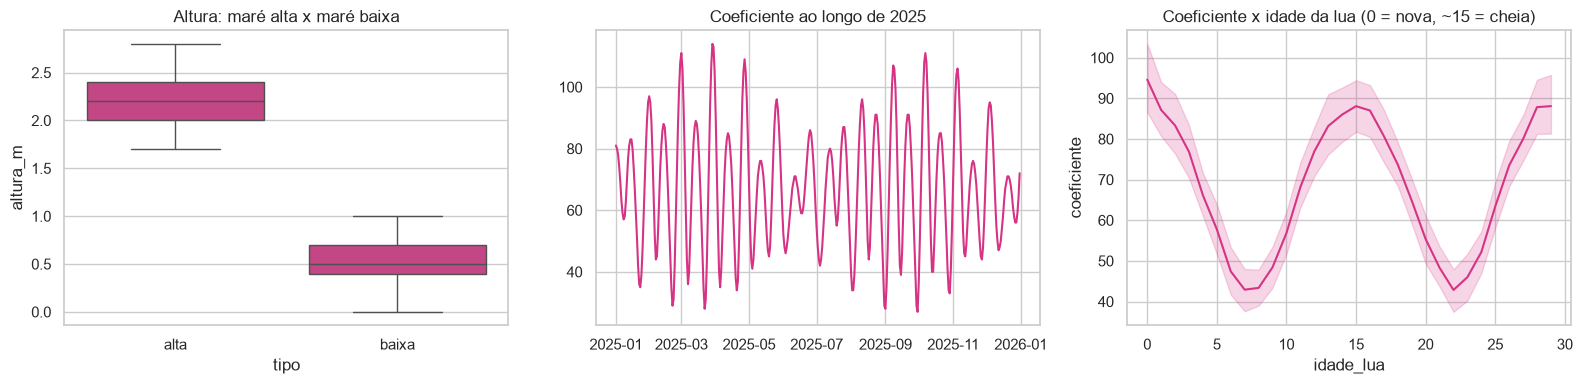

In [9]:
dias = mares.drop_duplicates("data")
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
sns.boxplot(data=mares, x="tipo", y="altura_m", ax=ax[0])
ax[0].set_title("Altura: maré alta x maré baixa")

ax[1].plot(dias["data"], dias["coeficiente"])
ax[1].set_title("Coeficiente ao longo de 2025")

sns.lineplot(data=dias, x="idade_lua", y="coeficiente", ax=ax[2])
ax[2].set_title("Coeficiente x idade da lua (0 = nova, ~15 = cheia)")
plt.tight_layout()

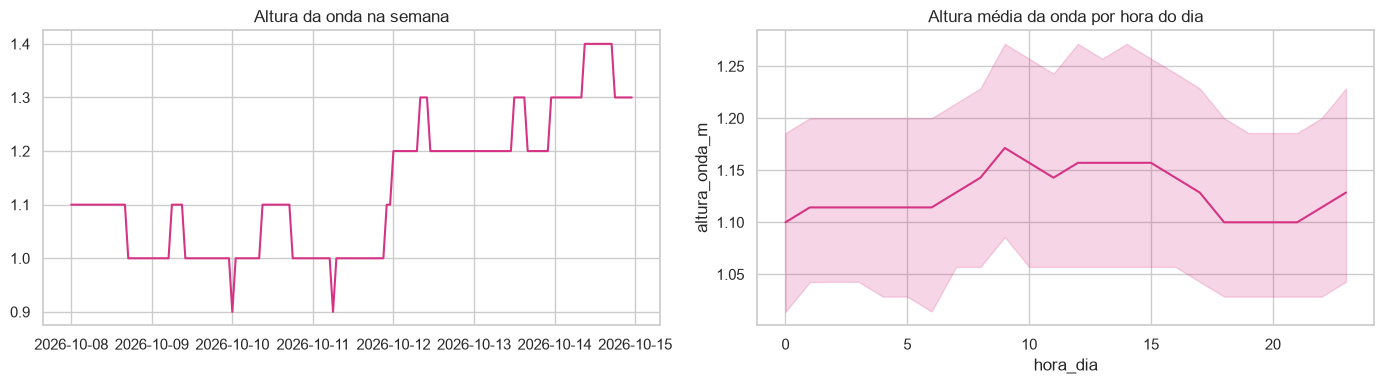

In [10]:
ondas["hora_dia"] = ondas["datahora"].dt.hour

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(ondas["datahora"], ondas["altura_onda_m"])
ax[0].set_title("Altura da onda na semana")

sns.lineplot(data=ondas, x="hora_dia", y="altura_onda_m", ax=ax[1])
ax[1].set_title("Altura média da onda por hora do dia")
plt.tight_layout()

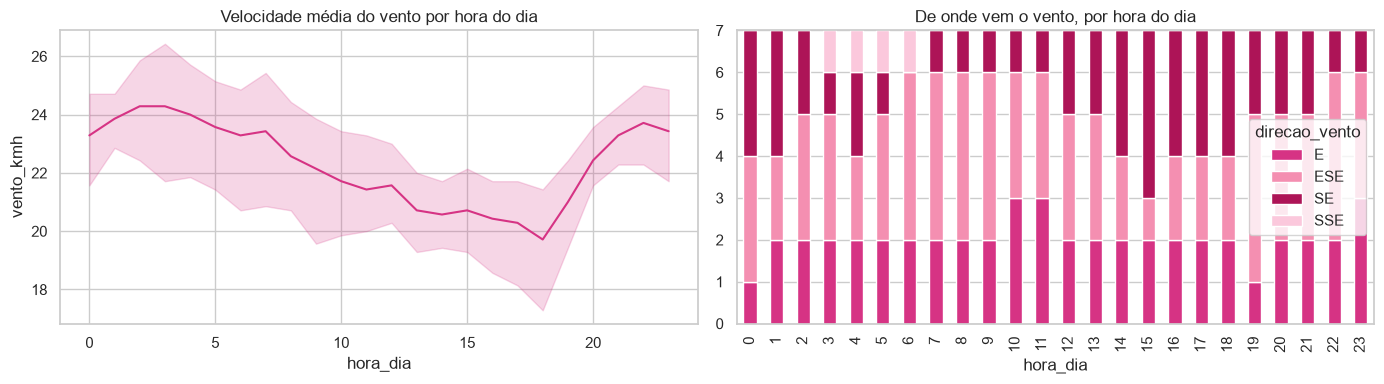

In [11]:
vento["hora_dia"] = vento["datahora"].dt.hour

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.lineplot(data=vento, x="hora_dia", y="vento_kmh", ax=ax[0])
ax[0].set_title("Velocidade média do vento por hora do dia")

pd.crosstab(vento["hora_dia"], vento["direcao_vento"]).plot(kind="bar", stacked=True, ax=ax[1])
ax[1].set_title("De onde vem o vento, por hora do dia")
plt.tight_layout()

## 4. Juntar as tabelas

Esta é a parte difícil, e ela tem mais de uma resposta certa.

As granularidades não batem: onda e vento são leituras horárias; maré são ~4
eventos por dia (os instantes de máxima e mínima). Para ter uma linha por hora
com as três informações você precisa decidir:

- Como levar a maré para a grade horária? Interpolar entre eventos? Repetir o
  último valor? Guardar apenas se a maré está subindo ou descendo? O que cada
  escolha assume sobre a curva real da maré — e onde essa suposição erra?
- Qual o tipo de junção? A previsão de onda e a de vento cobrem exatamente as
  mesmas horas? Se não, você mantém as horas incompletas ou corta?
- Que variáveis derivadas de tempo ajudam a responder a pergunta do projeto
  (dia da semana, período do dia, ...)?

Justifique as escolhas em markdown. Elas são a base das duas próximas etapas.

## 5. Visualizações voltadas à pergunta

Agora com a tabela junta: quando as condições coincidem?

- As horas de onda maior são as mesmas de vento mais fraco, ou elas se
  desencontram?
- Existe relação visível entre altura da maré e altura da onda?
- Quais dias e horas da janela se destacam?

Prefira poucos gráficos legíveis a muitos gráficos.

## 6. Salvar o dataset processado

Grave o resultado em `../data/processed/dataset.csv`. A Etapa 3 lê esse
arquivo — se as colunas mudarem depois, o notebook de ML muda também.

## 7. Conclusões

Em texto, sem código:

1. O que os dados mostram sobre as condições da janela coletada?
2. Que decisão de limpeza ou de junção você tomou que mais influencia o
   resultado, e por quê?
3. O que esses dados **não** permitem afirmar?